In [6]:
import sys,os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report



In [7]:
__script_path=os.path.abspath(globals().get('__file__','.'))
__script_dir = os.path.dirname(__script_path)
root_dir = os.path.abspath(f'{__script_dir}')
print(root_dir)
for lib in [root_dir][::-1]:
    if lib in sys.path:
        sys.path.remove(lib)
    sys.path.insert(0,lib)

from scripts.path_configs import *


/home/dinhtanloc/Projects/loan_ml_prediction_system
/home/dinhtanloc/Projects/loan_ml_prediction_system


In [9]:
df=pd.read_csv(f'{data_dir}/loan_data.csv')

tar_column='loan_status'
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


# 1. EDA

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [11]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


Text(0.5, 1.0, 'Pie chart')

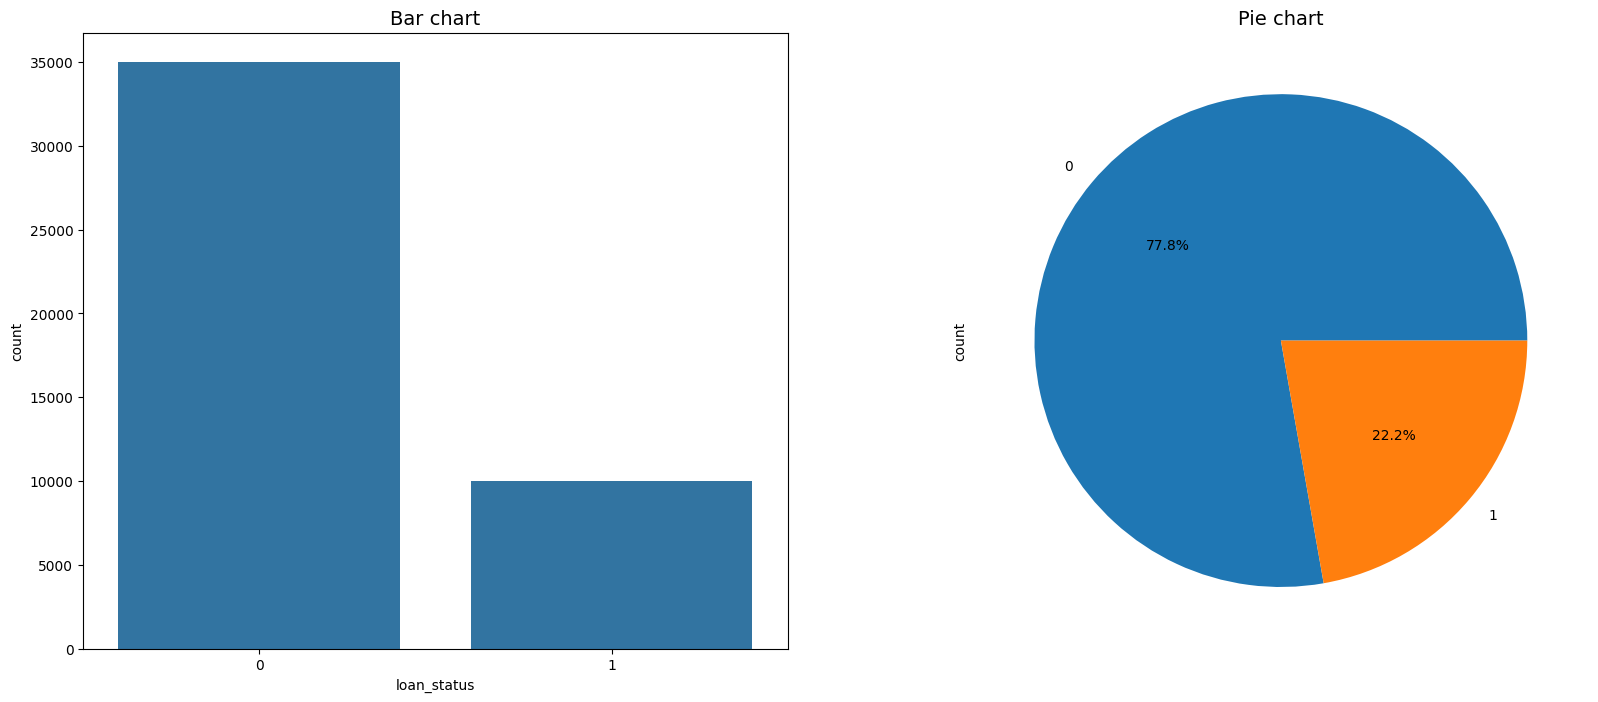

In [12]:
f, ax = plt.subplots(ncols= 2, figsize=(20,8))

sns.countplot(x=tar_column, data=df,ax=ax[0])
ax[0].set_title("Bar chart", fontsize=14)
df[tar_column].value_counts().plot(kind='pie', autopct='%.1f%%', ax=ax[1])
ax[1].set_title("Pie chart", fontsize=14)

In [13]:
All_cols=df.columns.tolist()[:-1]
All_cols

['person_age',
 'person_gender',
 'person_education',
 'person_income',
 'person_emp_exp',
 'person_home_ownership',
 'loan_amnt',
 'loan_intent',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_cred_hist_length',
 'credit_score',
 'previous_loan_defaults_on_file']

In [14]:
Num_col=df.select_dtypes('number').columns.tolist()[:-1]
Cat_col=df.select_dtypes('object').columns.tolist()
print(f"Numeric columns: {len(Num_col)} and Categorical columns: {len(Cat_col)}")

Numeric columns: 8 and Categorical columns: 5


In [15]:
for col in Cat_col:
  print(f'{col}: {df[col].nunique()}')

person_gender: 2
person_education: 5
person_home_ownership: 4
loan_intent: 6
previous_loan_defaults_on_file: 2


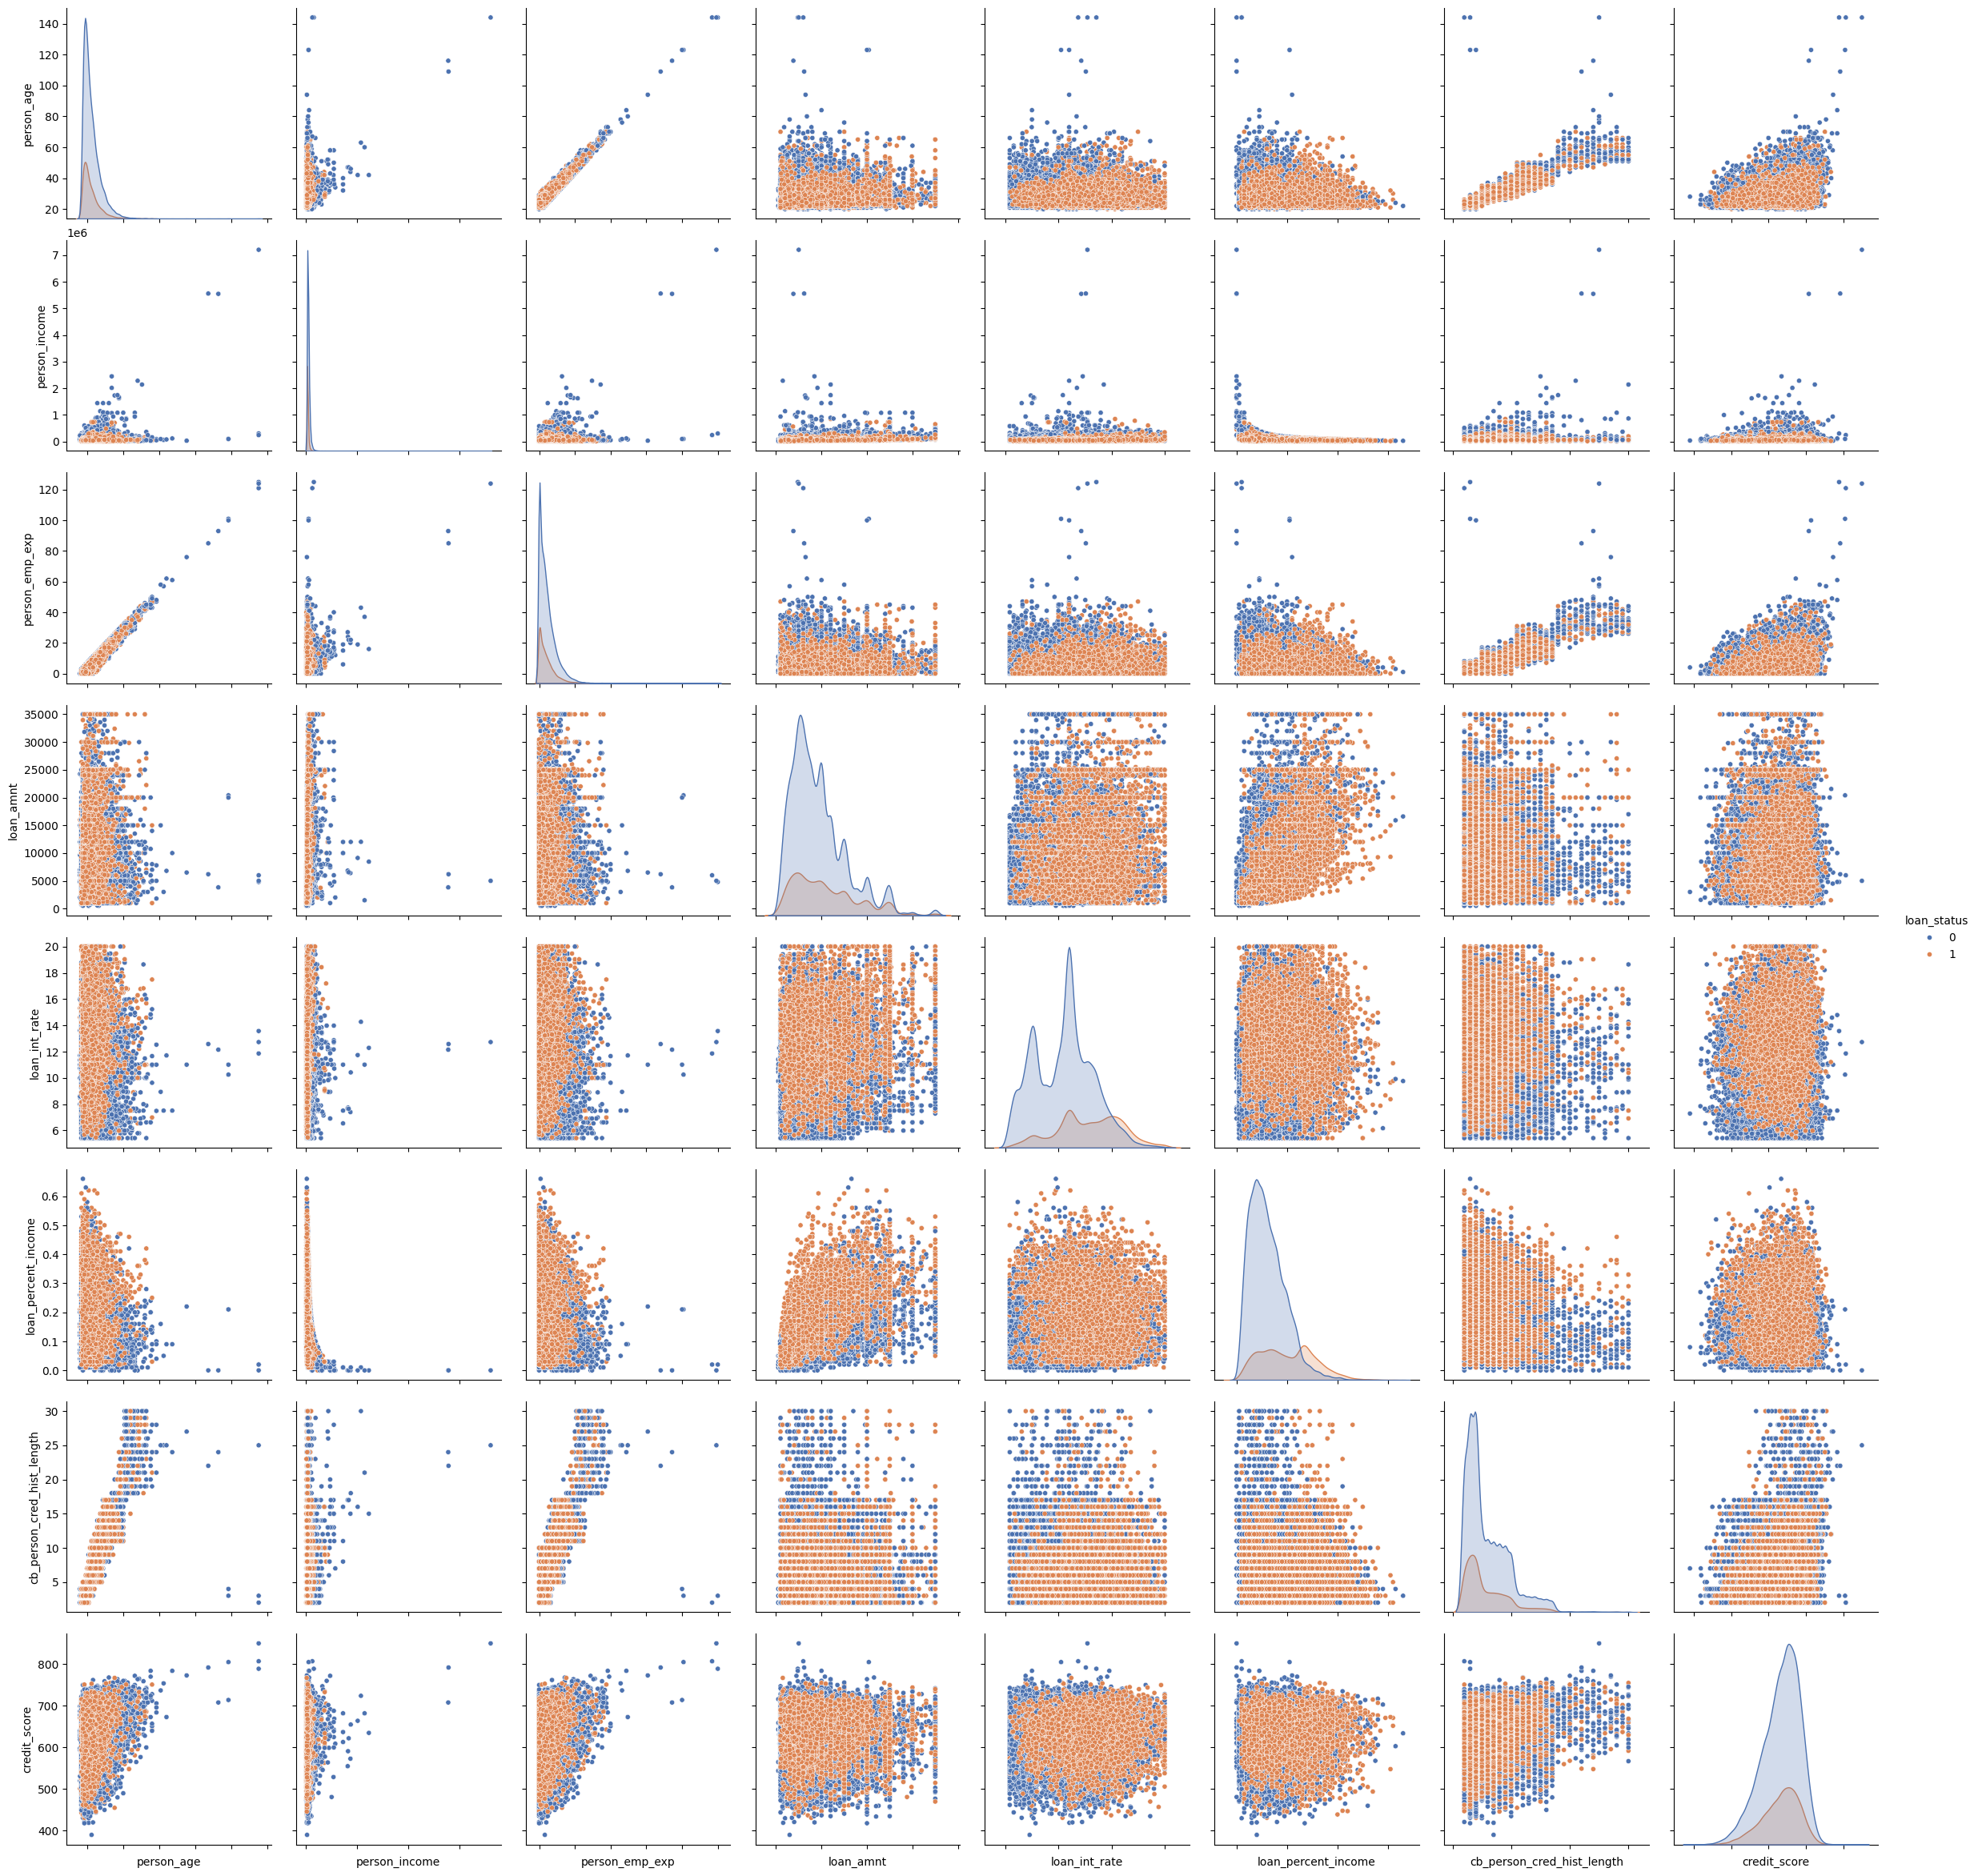

In [16]:
pp = sns.pairplot(df[Num_col + [tar_column]],
                 hue=tar_column,
                 palette='deep',
                 height=3,
                 diag_kind='kde',
                 diag_kws=dict(fill=True),
                 plot_kws=dict(s=20))

pp.set(xticklabels=[])
plt.show()

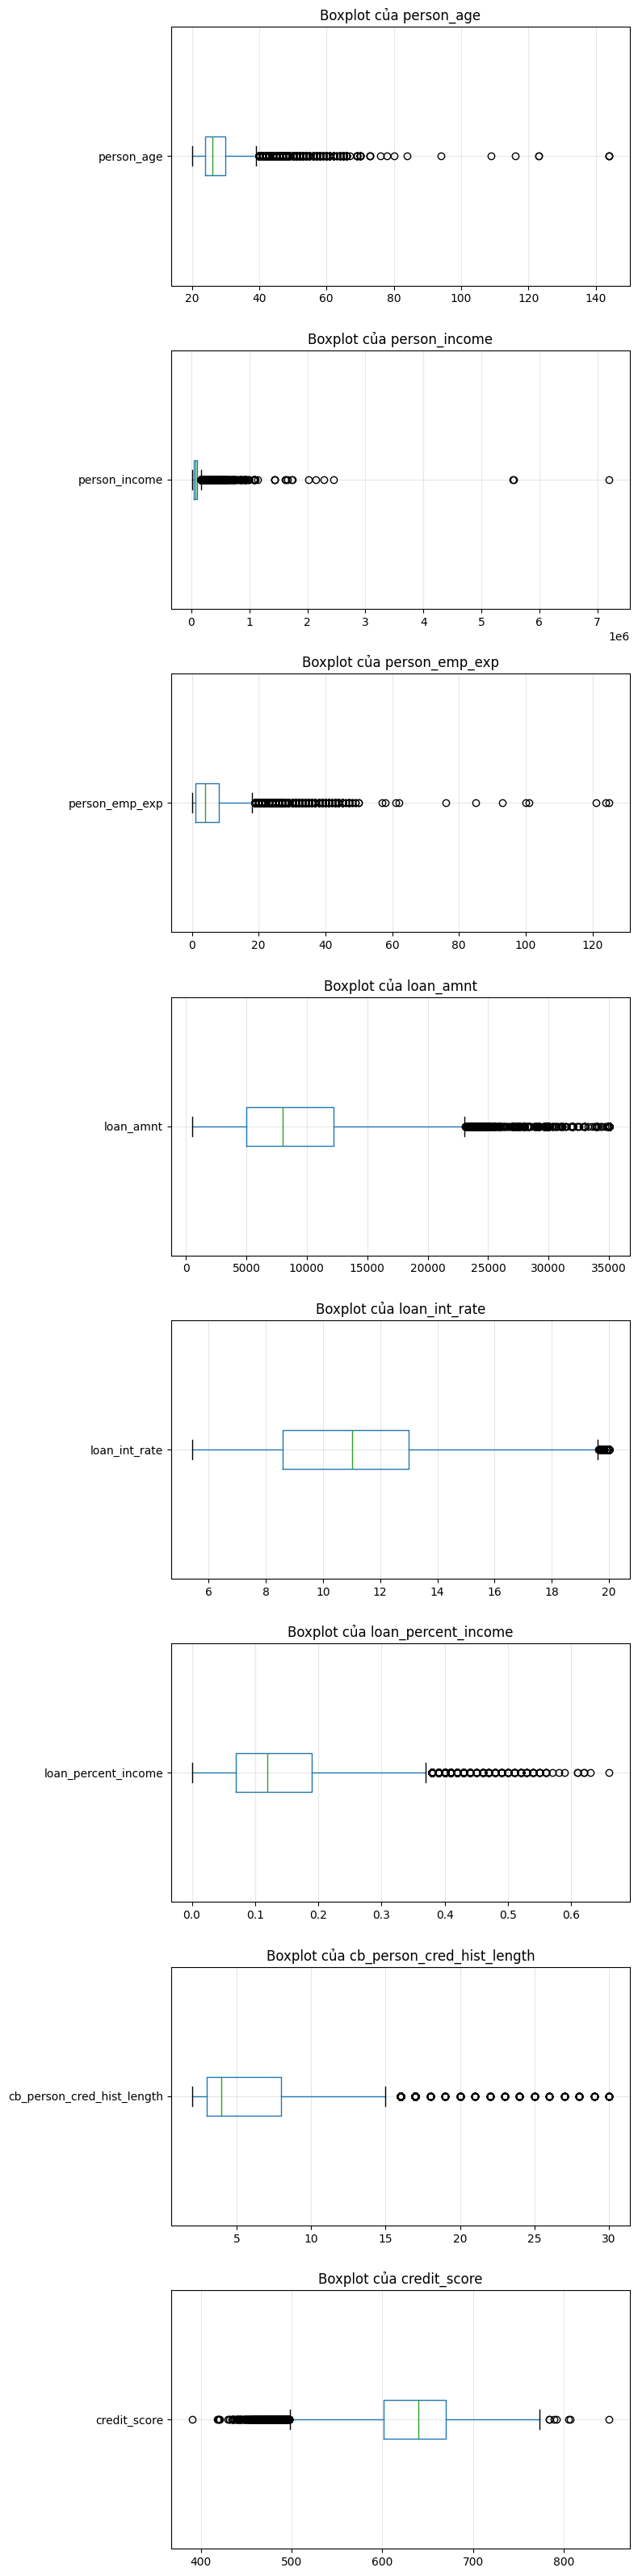

In [17]:
def plot_boxplots(df, numeric_columns):
    n = len(numeric_columns)
    fig, axes = plt.subplots(nrows=n, figsize=(8, 4*n))  

    for i, col in enumerate(numeric_columns):
        df.boxplot(column=col, ax=axes[i], vert=False)  
        axes[i].set_title(f"Boxplot của {col}", fontsize=12)
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()  
    plt.show()

# Gọi hàm
plot_boxplots(df, Num_col)

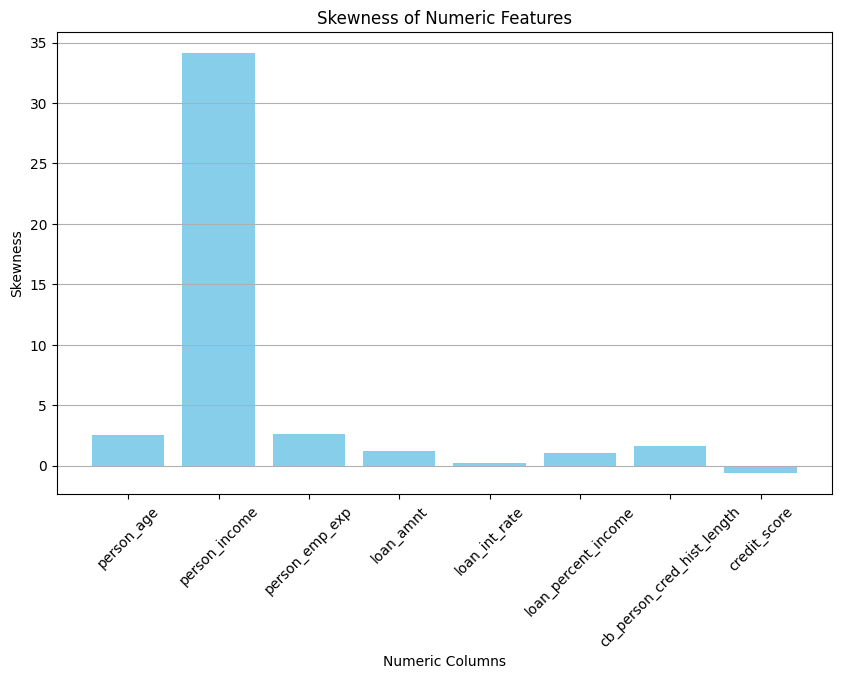

In [18]:
from scipy.stats import skew
skewness = skew(df[Num_col])

# Draw skewness using matplotlib
plt.figure(figsize=(10, 6))
plt.bar(Num_col, skewness, color='skyblue')
plt.xlabel('Numeric Columns')
plt.ylabel('Skewness')
plt.title('Skewness of Numeric Features')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

In [19]:
corr_matrix = df[Num_col + [tar_column]].corr()
corr_matrix

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
person_age,1.000000,0.193698,0.954412,0.050750,0.013402,-0.043299,0.861985,0.178432,-0.021476
person_income,0.193698,1.000000,0.185987,0.242290,0.001510,-0.234177,0.124316,0.035919,-0.135808
person_emp_exp,0.954412,0.185987,1.000000,0.044589,0.016631,-0.039862,0.824272,0.186196,-0.020481
loan_amnt,0.050750,0.242290,0.044589,1.000000,0.146093,0.593011,0.042969,0.009074,0.107714
loan_int_rate,0.013402,0.001510,0.016631,0.146093,1.000000,0.125209,0.018008,0.011498,0.332005
loan_percent_income,-0.043299,-0.234177,-0.039862,0.593011,0.125209,1.000000,-0.031868,-0.011483,0.384880
cb_person_cred_hist_length,0.861985,0.124316,0.824272,0.042969,0.018008,-0.031868,1.000000,0.155204,-0.014851
credit_score,0.178432,0.035919,0.186196,0.009074,0.011498,-0.011483,0.155204,1.000000,-0.007647
loan_status,-0.021476,-0.135808,-0.020481,0.107714,0.332005,0.384880,-0.014851,-0.007647,1.000000


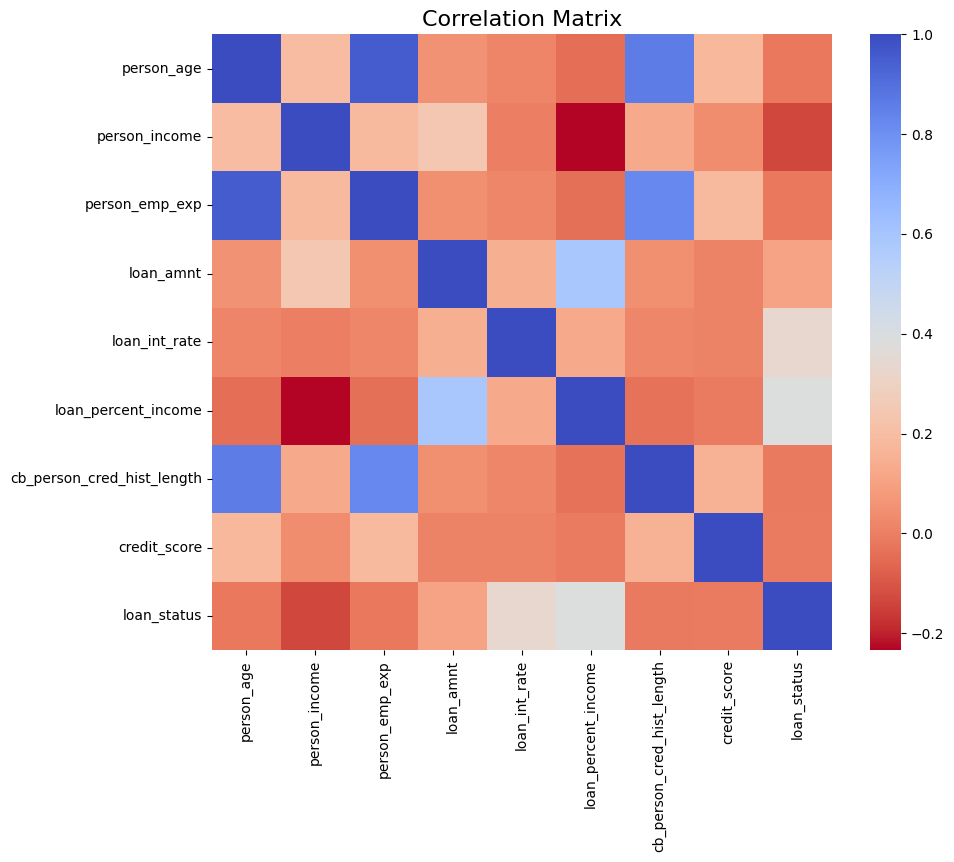

In [20]:
f, ax1 = plt.subplots(1, 1, figsize=(10,8))

sns.heatmap(corr_matrix, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax1)
ax1.set_title('Correlation Matrix', fontsize=16)
plt.show()

In [21]:
corr_matrix[tar_column].sort_values()

person_income                -0.135808
person_age                   -0.021476
person_emp_exp               -0.020481
cb_person_cred_hist_length   -0.014851
credit_score                 -0.007647
loan_amnt                     0.107714
loan_int_rate                 0.332005
loan_percent_income           0.384880
loan_status                   1.000000
Name: loan_status, dtype: float64